In [3]:
import os

figdir = os.path.join('..', 'figures')
corr = 'spearman'
data_dir_1 = os.path.join('..', 'data', 'case_study_1_revised')
data_dir_2 = os.path.join('..', 'data', 'case_study_2_revised')
result_dir_1 = os.path.join('..', 'results', 'case_study_1_revised')
result_dir_2 = os.path.join('..', 'results', 'case_study_2_revised')

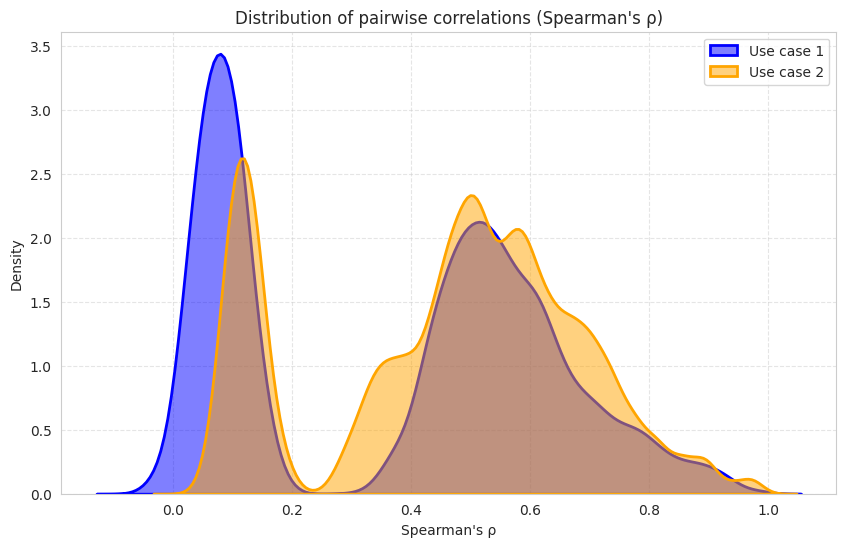

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the CSV for data_dir_1
df1 = pd.read_csv(os.path.join(data_dir_1, 'correlations.csv'), sep=";")
df1 = df1[df1["source"] != df1["target"]]  # Exclude self-correlations
df1 = df1[df1["source"] < df1["target"]]   # Exclude reverse pairs

# Load the CSV for data_dir_2
df2 = pd.read_csv(os.path.join(data_dir_2, 'correlations.csv'), sep=";")
df2 = df2[df2["source"] != df2["target"]]  # Exclude self-correlations
df2 = df2[df2["source"] < df2["target"]]   # Exclude reverse pairs

# Plot the distributions as smooth curves (KDE)
plt.figure(figsize=(10, 6))
sns.kdeplot(df1['spearman'], fill=True, color="blue", linewidth=2, label="Use case 1", alpha=0.5)
sns.kdeplot(df2['spearman'], fill=True, color="orange", linewidth=2, label="Use case 2", alpha=0.5)

plt.xlabel("Spearman's ρ")
plt.ylabel("Density")
plt.title("Distribution of pairwise correlations (Spearman's ρ)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


# Feature importances latex table code generator

In [37]:
import json
import numpy as np
import pandas as pd
import os

nb_iter = 10
case = 2
dataset = 'valid'

# Load data
classifier_clusters = pd.read_csv(os.path.join(result_dir_2, f'classifier_{dataset}_clusters.csv'), delimiter=';')
max_train_size = classifier_clusters.loc[classifier_clusters['iteration'] == nb_iter, 'train_size'].max()
clusters = 4

selected_row = classifier_clusters[
    (classifier_clusters['train_size'] == max_train_size) &
    (classifier_clusters['nb_clusters'] == clusters)]

# Calculate mean F1-score for selected rows
mean_f1_score = selected_row['f1_score'].mean()
mean_recall = selected_row['recall'].mean()
mean_precision = selected_row['precision'].mean()

importances = []
for str_importance in selected_row['feature_importance'].tolist():
    # Clean and parse JSON
    cleaned_str = str_importance.replace("np.float64(", "").replace(")", "").replace("'", '"')
    importances.append(json.loads(cleaned_str))

# Collect all unique feature names across all dictionaries
all_features = set()
for imp in importances:
    all_features.update(imp.keys())
all_features = list(all_features)

# Initialize results with 0 for all features
results = {feature: {'mean': 0, 'min': 0, 'max': 0} for feature in all_features}

# Calculate mean, min, max for each feature (0 if missing)
for feature in all_features:
    values = []
    for imp in importances:
        values.append(imp.get(feature, 0))
    mean = np.mean(values)
    min_val = np.min(values)
    max_val = np.max(values)
    results[feature] = {'mean': mean, 'min': min_val, 'max': max_val}

# Sort features by descending mean importance
sorted_features = sorted(results.keys(), key=lambda x: results[x]['mean'], reverse=True)

# Generate LaTeX table
latex_table = r"""
\begin{table}
  \caption{""" + f'Feature importances on {clusters} clusters of {dataset} dataset of study case {case} (F1-score: {mean_f1_score:.3f}, recall: {mean_recall:.3f}, precision: {mean_precision:.3f})' + r"""
  \label{tab:""" + f'feat_{dataset}_{case}' + r"""}
  \begin{tabular}{lc}
  \toprule
  \textbf{Feature} & \textbf{Importance [min-max]} \\
  \midrule
""" + "\n".join(
    f"{feature.replace('_', ' ').replace('/', ' ').title()} & {results[feature]['mean']*100:.1f}\% [{results[feature]['min']*100:.1f}-{results[feature]['max']*100:.1f}] \\\\"
    for feature in sorted_features
) + r"""
  \bottomrule
  \end{tabular}
\end{table}
"""

print(latex_table)



\begin{table}
  \caption{Feature importances on 4 clusters of valid dataset of study case 2 (F1-score: 0.954, recall: 0.951, precision: 0.969)
  \label{tab:feat_valid_2}
  \begin{tabular}{lc}
  \toprule
  \textbf{Feature} & \textbf{Importance [min-max]} \\
  \midrule
Signal Modeling Nuisance Regressors Motion & 30.1\% [22.7-37.0] \\
Coregistration Cost Function Normalised Cross Correlation & 29.3\% [24.8-38.6] \\
Signal Modeling Temporal Noise Autocorrelation Ar1 & 23.6\% [0.0-42.6] \\
Signal Modeling Temporal Noise Autocorrelation Fast & 10.7\% [0.0-33.5] \\
Signal Modeling Nuisance Regressors & 4.4\% [0.0-13.1] \\
Signal Modeling Hrf Temporal Dispersion Derivs & 1.2\% [0.0-10.7] \\
Slice Timing Correction Ref Slice First & 0.6\% [0.0-5.5] \\
  \bottomrule
  \end{tabular}
\end{table}


<>:62: SyntaxWarning: invalid escape sequence '\%'
<>:62: SyntaxWarning: invalid escape sequence '\%'
/home/ymerel/tmp/ipykernel_171465/1308774346.py:62: SyntaxWarning: invalid escape sequence '\%'
  f"{feature.replace('_', ' ').replace('/', ' ').title()} & {results[feature]['mean']*100:.1f}\% [{results[feature]['min']*100:.1f}-{results[feature]['max']*100:.1f}] \\\\"


In [41]:
import ast
import pandas as pd

classifier_valid_thresholds_1 = pd.read_csv(os.path.join(result_dir_1, f'classifier_valid_thresholds.csv'), delimiter=';')
max_train_size_1 = classifier_valid_thresholds_1.loc[classifier_valid_thresholds_1['iteration'] == nb_iter, 'train_size'].max()
# threshold_1 = 0.007
threshold_1 = 0.108
selected_row_1 = classifier_valid_thresholds_1[
    (classifier_valid_thresholds_1['train_size'] == max_train_size_1) &
    (classifier_valid_thresholds_1['threshold'] == threshold_1) &
    (classifier_valid_thresholds_1['iteration'] == nb_iter)
]
feat_imp_1 = json.loads(selected_row_1['feature_importance'].item().replace("np.float64(", "").replace(")", "").replace("'", '"'))
print(selected_row_1)

      train_size  f1_score                                 feature_importance  \
8369         520    0.9571  {'slice_timing_correction/ref_slice/middle': n...   

                                          decision_tree  nb_features  \
8369  digraph Tree {\nnode [shape=box, style="filled...           14   

      nb_clusters  silhouette_score    recall  precision  threshold  iteration  
8369           37          0.433864  0.959459   0.960811      0.108         10  


In [7]:
classifier_valid_thresholds_2 = pd.read_csv(os.path.join(result_dir_2, f'classifier_valid_thresholds.csv'), delimiter=';')
max_train_size_2 = classifier_valid_thresholds_2.loc[classifier_valid_thresholds_2['iteration'] == nb_iter, 'train_size'].max()
threshold_2 = 0.060

selected_row_2 = classifier_valid_thresholds_2[
    (classifier_valid_thresholds_2['train_size'] == max_train_size_2) &
    (classifier_valid_thresholds_2['threshold'] == threshold_2) &
    (classifier_valid_thresholds_2['iteration'] == nb_iter)
]
print(selected_row_2)
feat_imp_2 = json.loads(selected_row_2['feature_importance'].item().replace("np.float64(", "").replace(")", "").replace("'", '"'))

       train_size  f1_score  \
12689         608  0.924902   

                                      feature_importance  \
12689  {'slice_timing_correction/ref_slice/middle': n...   

                                           decision_tree  nb_features  \
12689  digraph Tree {\nnode [shape=box, style="filled...           18   

       nb_clusters  silhouette_score    recall  precision  threshold  \
12689          114          0.466686  0.932549   0.929902       0.06   

       iteration  
12689         10  


# Feature importance (valid configurations)

In [26]:
import pandas as pd

step_labels = {
    "signal_modeling" : "Signal modeling",
    "motion_correction_realignment" : "Motion correction",
    "coregistration" : "Coregistration",
    "slice_timing_correction" : "Slice timing",
    "spatial_normalization" : "Spatial normalization",
    "spatial_smoothing" : "Smoothing"
}

param_labels = {
    "ref_slice" : "Ref. slice",
    "hrf" : "HRF",
    "cost_function" : "Cost func.",
    "register_to" : "Register to",
    "interpolation" : "Interpolation",
    "nuisance_regressors" : "Nuisance regressors",
    "fwhm" : "FWHM",
    "source_target" : "Source - target",
    "temporal_noise_autocorrelation" : "Temporal correlation"
    
}

val_labels = {
    "bspline" : "B-Spline",
    "first" : "First",
    "motion" : "Motion",
    "nearest_neighbour" : "Nearest neighbour",
    "anat_on_func" : "Anat. on func.",
    "func_on_anat" : "Func. on anat.",
    "normalised_cross_correlation" : "Normalised cross correlation",
    "temporal_derivs" : "1 deriv.",
    "temporal_dispersion_derivs" : "2 derivs.",
    "canonical" : "Canonical",
    "AR1" : "AR(1)",
    "mean" : "Mean",
    "normalised_mutual_information" : "Normalised mutual info.",
    "mutual_information" : "Mutual info.",
    "middle" : "Middle",
    "FAST" : "FAST",
    "trilinear" : "Trilinear",
    "entropy_correlation_coefficient" : "Entropy correlation coeff."
    
}

def process_feat_imp(data_dict, case_id):
    processed = []
    for key, percentage in data_dict.items():
        if percentage == 0:
            continue
            
        parts = key.split('/')
        step = parts[0] if len(parts) > 0 else None
        if step in step_labels.keys():
            step = step_labels[step]
        param = parts[1] if len(parts) > 1 else "Not selected"
        if param in param_labels.keys():
            param = param_labels[param]
        val = parts[2] if len(parts) > 2 else None
        if param == "Nuisance regressors" and val is None:
            val = "0"
        if val in val_labels.keys():
            val = val_labels[val]
        
        processed.append({
            "case study": case_id,
            "step": step,
            "parameter": param,
            "value": val,
            "percentage": percentage * 100
        })
    return processed

data = process_feat_imp(feat_imp_1, 1) + process_feat_imp(feat_imp_2, 2)

# Create the final DataFrame
df = pd.DataFrame(data)
df.head(50)

,case study,step,parameter,value,percentage
0,1,Slice timing,Ref. slice,Middle,2.244910
1,1,Signal modeling,Temporal correlation,FAST,3.335068
2,1,Slice timing,Not selected,None,0.621756
3,1,Signal modeling,Temporal correlation,AR(1),0.605491
4,1,Signal modeling,HRF,Canonical,8.356910
5,1,Motion correction,Register to,First,0.269107
6,1,Coregistration,Source - target,Func. on anat.,7.796071
7,1,Coregistration,Cost func.,Mutual info.,0.201830
8,1,Signal modeling,HRF,2 derivs.,16.456575
9,1,Slice timing,Ref. slice,None,1.835910


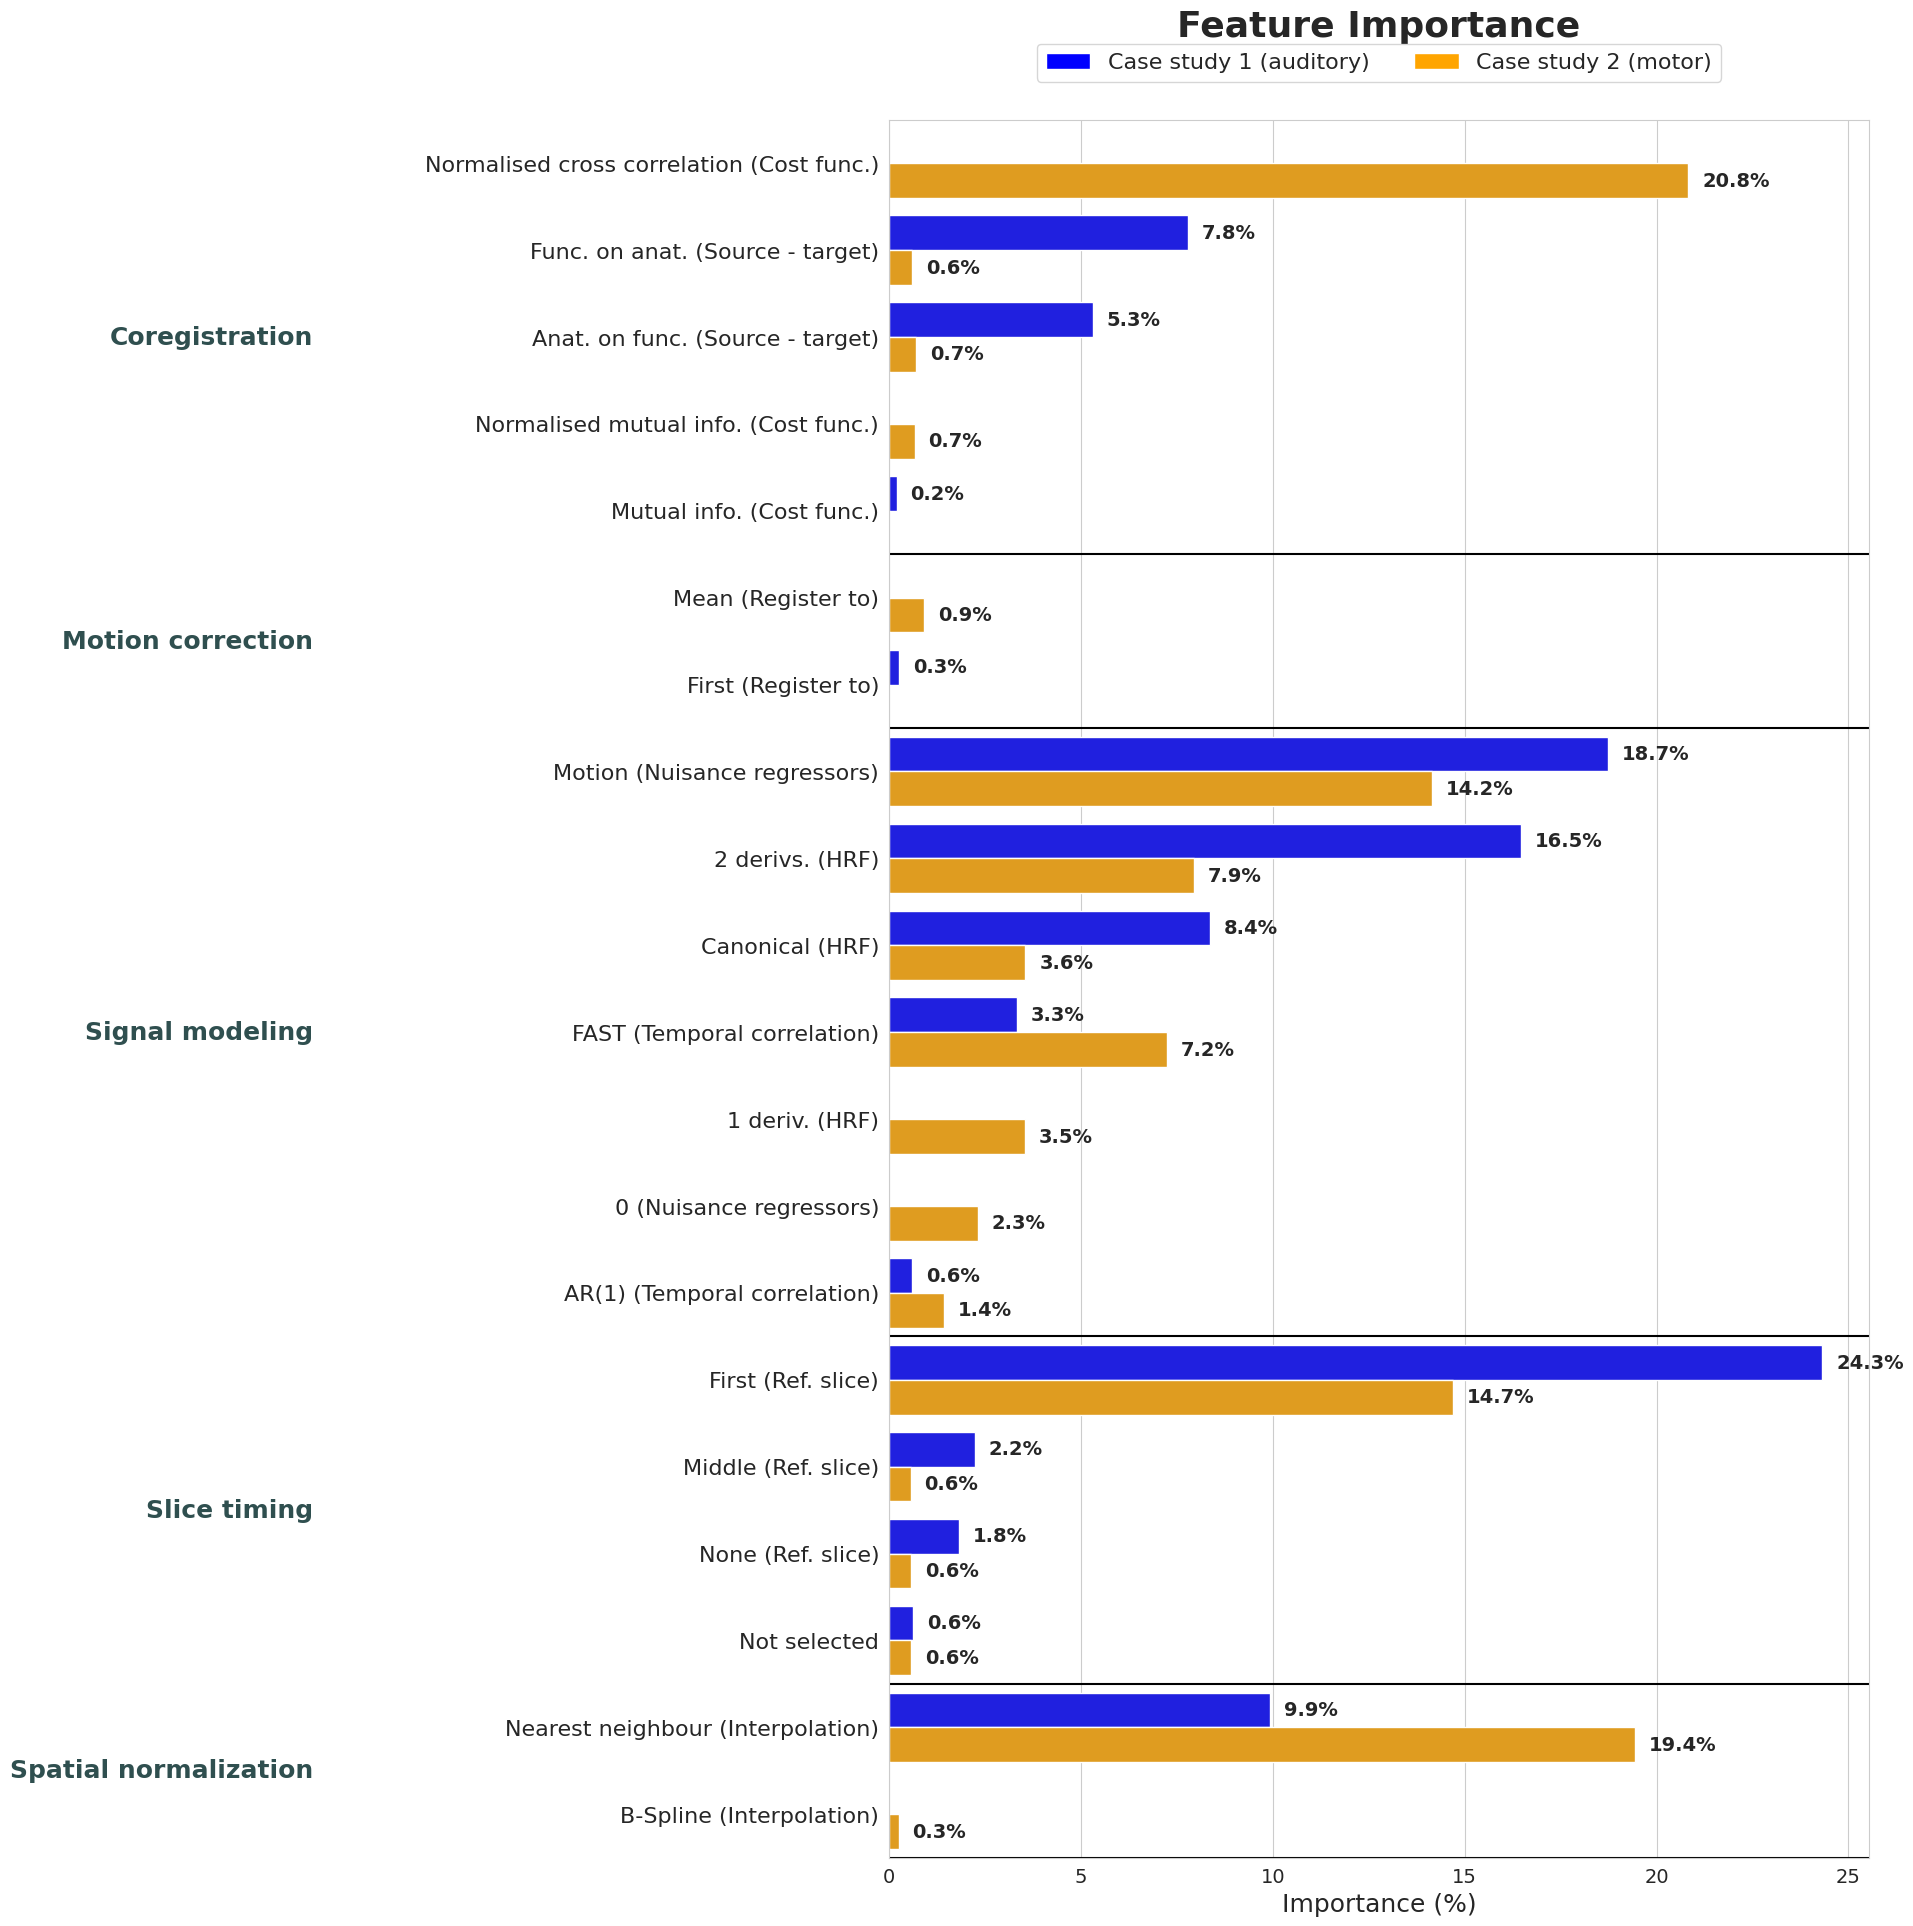

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1. Prepare Data
df['label'] = df.apply(
    lambda x: f"{x['parameter']}" if x['parameter'] == "Not selected" 
    else f"{x['value']} ({x['parameter']})", 
    axis=1
)
df = df[df['percentage'] > 0].copy()

# Calculate the mean percentage per label/step to determine order
df['mean_val'] = df.groupby(['step', 'label'])['percentage'].transform('mean')
df = df.sort_values(by=['step', 'mean_val'], ascending=[True, False])

# 2. Create Figure
# Added extra vertical space for the legend above the plot
plt.figure(figsize=(14, len(df['label'].unique()) * 1.1))

# 3. Plot
ax = sns.barplot(
    data=df, x="percentage", y="label", hue="case study", 
    palette={1: "blue", 2: "orange"}, orient="h"
)

# 4. Add Step Labels (Horizontal at the start of each group)
# Add extra space on the left for the step labels
plt.subplots_adjust(left=0.2, top=0.9) 

steps = df['step'].unique()
current_y = -0.5
for step in steps:
    step_count = len(df[df['step'] == step]['label'].unique())
    # Place text horizontally at the start of the block
    plt.text(-15, current_y + (step_count / 2), step, 
             rotation=0, va='center', ha='right', 
             fontsize=18, fontweight='bold', color='darkslategray')
    plt.axhline(y=current_y + step_count, color='black', linewidth=1.5, linestyle='-')
    current_y += step_count

# 5. Styling and Font Sizes
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=10, fontsize=14, fontweight='bold')

plt.title("Feature Importance", fontsize=26, fontweight='bold', pad=60) # Increased pad
plt.xlabel("Importance (%)", fontsize=18)
plt.ylabel("", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=16)

# 6. Single-Line Global Legend
legend_elements = [
    Patch(facecolor='blue', label='Case study 1 (auditory)'),
    Patch(facecolor='orange', label='Case study 2 (motor)')
]
# Positioned at upper center, just below the title
plt.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 1.05), 
           ncol=2, fontsize=16, frameon=True)
plt.savefig(os.path.join(figdir, 'feature_importances.svg'), format='svg', bbox_inches='tight')
plt.savefig(os.path.join(figdir, 'feature_importances.png'), format='png', bbox_inches='tight')
plt.show()

{'slice_timing_correction/ref_slice/first', 'slice_timing_correction', 'coregistration/cost_function/normalised_cross_correlation', 'slice_timing_correction/ref_slice', 'signal_modeling/hrf/canonical', 'coregistration/cost_function/normalised_mutual_information', 'signal_modeling/temporal_noise_autocorrelation/FAST', 'signal_modeling/nuisance_regressors', 'coregistration/source_target/anat_on_func', 'motion_correction_realignment/register_to/first', 'slice_timing_correction/ref_slice/middle', 'spatial_normalization/interpolation/bspline', 'signal_modeling/hrf/temporal_dispersion_derivs', 'signal_modeling/nuisance_regressors/motion', 'signal_modeling/temporal_noise_autocorrelation/AR1', 'signal_modeling/hrf/temporal_derivs', 'coregistration/source_target/func_on_anat', 'spatial_normalization/interpolation/nearest_neighbour', 'motion_correction_realignment/register_to/mean', 'coregistration/cost_function/mutual_information'}


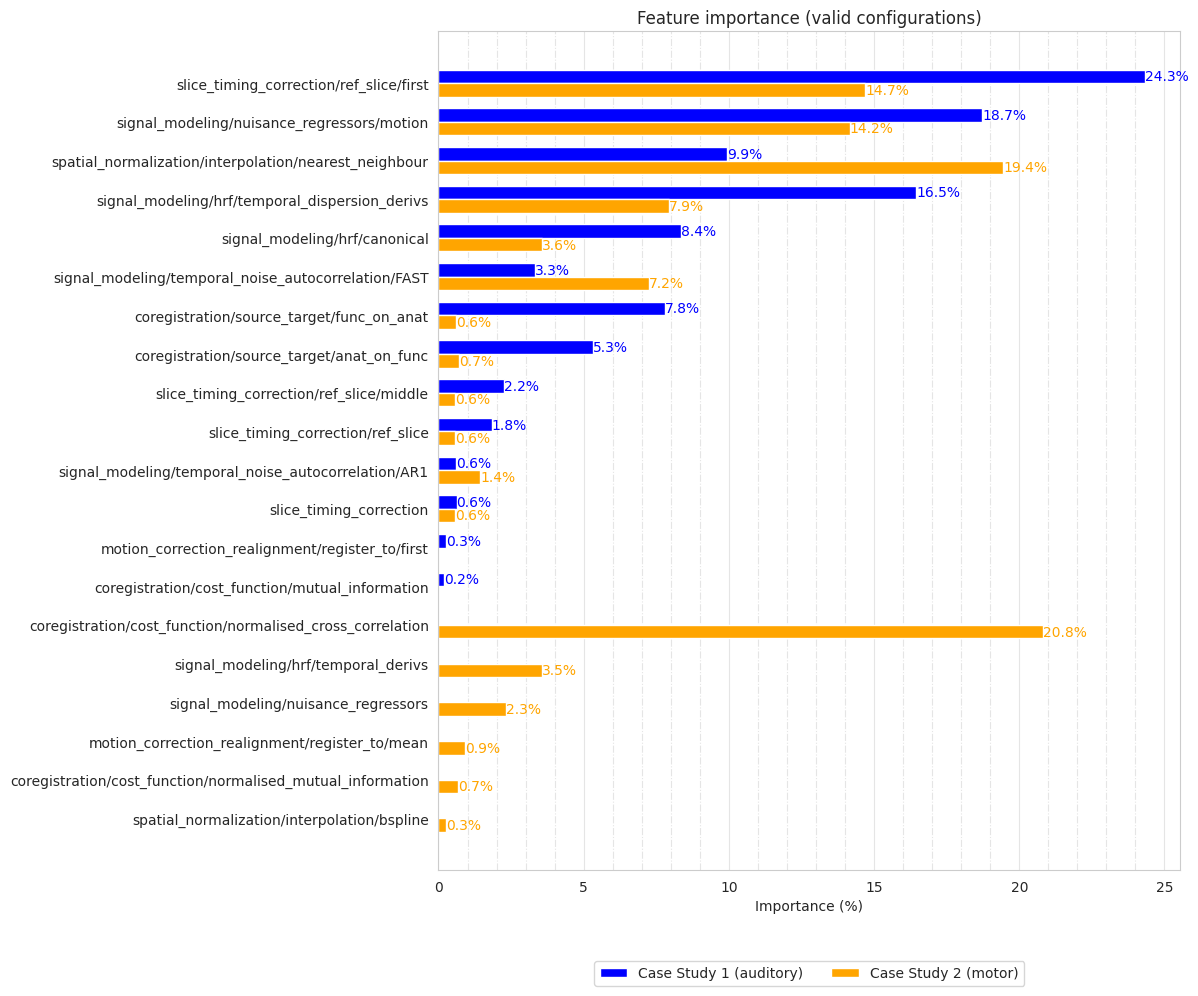

In [10]:
import numpy as np
from matplotlib import pyplot as plt

# Get all unique features
all_features = set(feat_imp_1.keys()).union(set(feat_imp_2.keys()))
print(all_features)

# Separate common and unique features
common_features = set(feat_imp_1.keys()).intersection(set(feat_imp_2.keys()))
unique_1 = set(feat_imp_1.keys()) - common_features
unique_2 = set(feat_imp_2.keys()) - common_features

# Order common features by decreasing mean importance
mean_importance = {f: (feat_imp_1[f] + feat_imp_2[f]) / 2 for f in common_features}
sorted_common = sorted(mean_importance.keys(), key=lambda x: mean_importance[x], reverse=True)

# Order unique features by decreasing importance
sorted_unique_1 = sorted(unique_1, key=lambda x: feat_imp_1[x], reverse=True)
sorted_unique_2 = sorted(unique_2, key=lambda x: feat_imp_2[x], reverse=True)

# Combine features in the desired order: common first, then unique_1, then unique_2
features = sorted_common + sorted_unique_1 + sorted_unique_2

# Align features and fill missing values with 0
importance_1 = [feat_imp_1.get(f, 0) for f in features]
importance_2 = [feat_imp_2.get(f, 0) for f in features]

# Convert to percentages
importance_1 = [i * 100 for i in importance_1]
importance_2 = [i * 100 for i in importance_2]

# Reverse the order to put common features on top
features = features[::-1]
importance_1 = importance_1[::-1]
importance_2 = importance_2[::-1]

# Plot
y = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 10))
rects1 = ax.barh(y + width/2, importance_1, width, color='blue', label='Case Study 1')
rects2 = ax.barh(y - width/2, importance_2, width, color='orange', label='Case Study 2')

# Add percentage values at the end of each bar, only if greater than 0
for i, (v1, v2) in enumerate(zip(importance_1, importance_2)):
    if v1 > 0:
        ax.text(v1, i + width/2, f'{v1:.1f}%', color='blue', va='center', ha='left')
    if v2 > 0:
        ax.text(v2, i - width/2, f'{v2:.1f}%', color='orange', va='center', ha='left')

ax.set_xlabel('Importance (%)')
ax.set_title('Feature importance (valid configurations)')

# Set y-tick labels and color them
ax.set_yticks(y)
ax.set_yticklabels(features)

# Add a custom legend entry for wrongly implemented and locked features
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='blue', label='Case Study 1 (auditory)'),
    Patch(facecolor='orange', label='Case Study 2 (motor)'),
]
ax.legend(handles=legend_elements, loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.1))

plt.grid(False)
plt.minorticks_on()
plt.grid(True, linestyle="-.", alpha=0.5, which='minor', axis='x')
plt.grid(True, alpha=0.5, which='major', axis='x')

plt.tight_layout()
plt.savefig(os.path.join(figdir, 'feature_importances.svg'), format='svg', bbox_inches='tight')
plt.savefig(os.path.join(figdir, 'feature_importances.png'), format='png', bbox_inches='tight')
plt.show()


['coregistration/cost_function/normalised_cross_correlation', 'signal_modeling/nuisance_regressors/motion', 'signal_modeling/temporal_noise_autocorrelation/AR1', 'coregistration/source_target/func_on_anat', 'signal_modeling/temporal_noise_autocorrelation/FAST', 'coregistration/source_target/anat_on_func', 'signal_modeling/nuisance_regressors']


NameError: name 'kos_features' is not defined

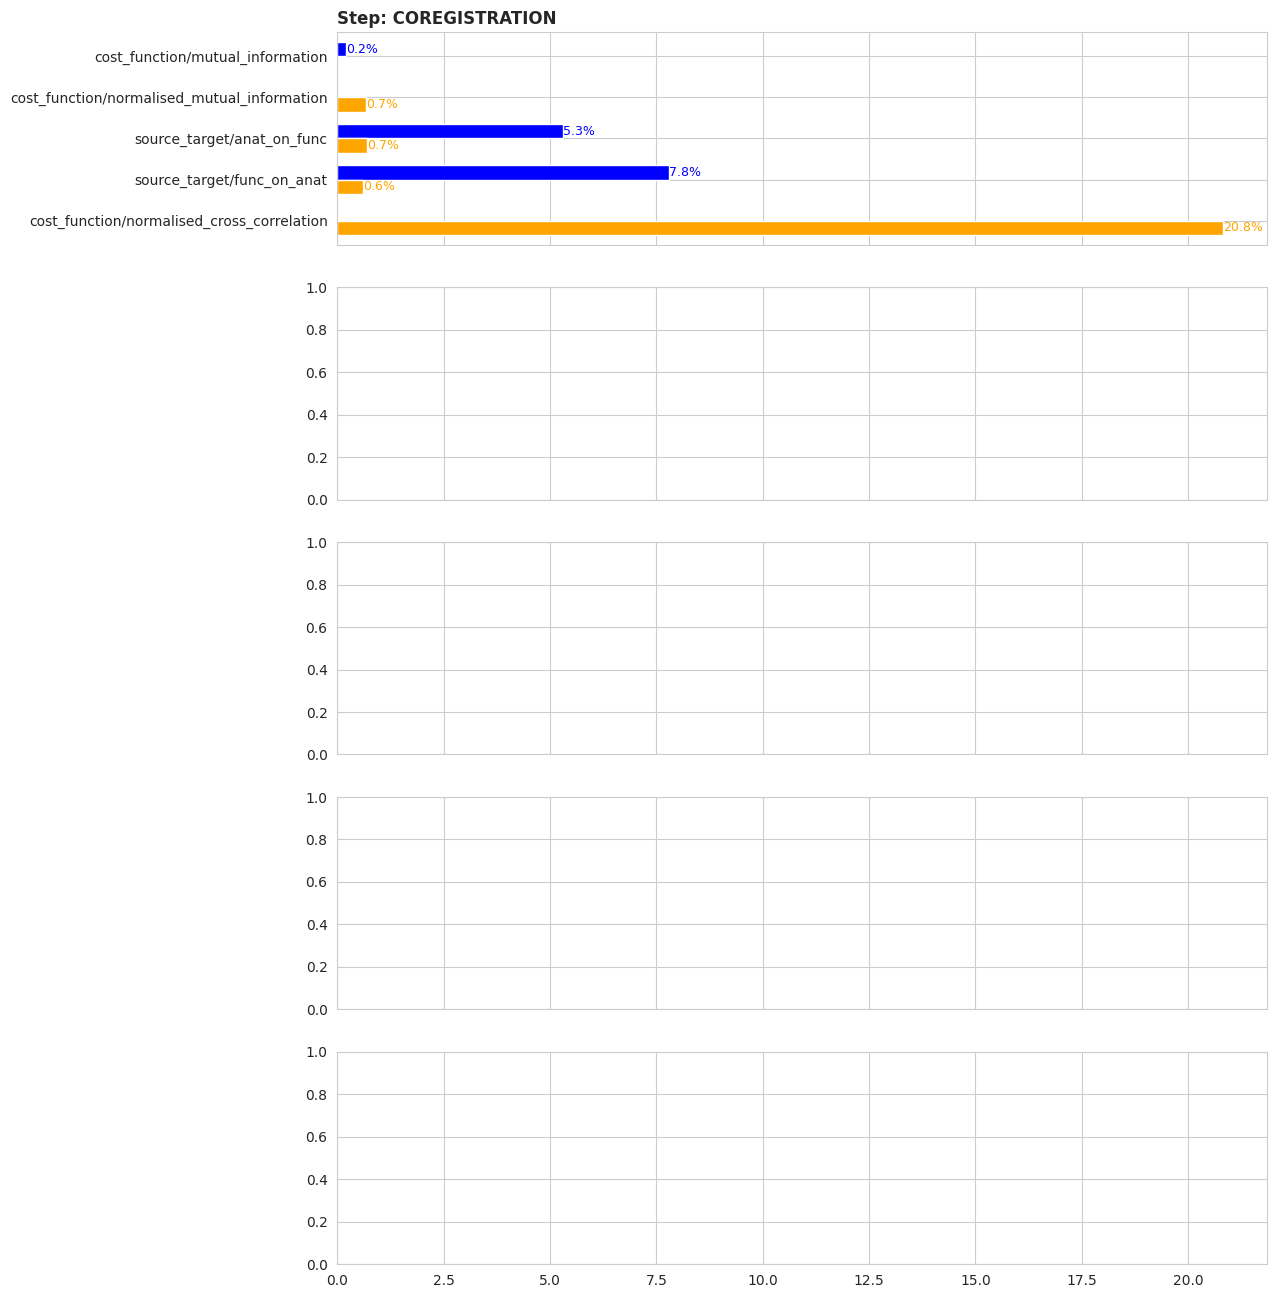

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# 1. Group features by their step
grouped_features = {}
all_features = set(feat_imp_1.keys()).union(set(feat_imp_2.keys()))

for feat in all_features:
    step = feat.split('/')[0]
    if step not in grouped_features:
        grouped_features[step] = []
    grouped_features[step].append(feat)

sorted_steps = sorted(grouped_features.keys())
print(sorted_features)

# 2. Setup figure for subplots
fig, axes = plt.subplots(len(sorted_steps), 1, figsize=(12, sum([len(grouped_features[s]) for s in sorted_steps]) * 0.8), sharex=True)

# Ensure axes is always iterable (in case there's only one step)
if len(sorted_steps) == 1:
    axes = [axes]

width = 0.35

# 3. Plot each step in its own axis
for ax, step in zip(axes, sorted_steps):
    # Sort features within this step
    feats = sorted(grouped_features[step], key=lambda f: (feat_imp_1.get(f, 0) + feat_imp_2.get(f, 0))/2, reverse=True)
    
    y = np.arange(len(feats))
    
    # Extract importances
    imp1 = [feat_imp_1.get(f, 0) * 100 for f in feats]
    imp2 = [feat_imp_2.get(f, 0) * 100 for f in feats]
    
    # Bars
    ax.barh(y + width/2, imp1, width, color='blue', label='Case Study 1')
    ax.barh(y - width/2, imp2, width, color='orange', label='Case Study 2')
    
    # Percentages
    for i, (v1, v2) in enumerate(zip(imp1, imp2)):
        if v1 > 0: ax.text(v1, i + width/2, f'{v1:.1f}%', color='blue', va='center', ha='left', fontsize=9)
        if v2 > 0: ax.text(v2, i - width/2, f'{v2:.1f}%', color='orange', va='center', ha='left', fontsize=9)
    
    # Truncate labels
    labels = ["/".join(f.split('/')[1:]) for f in feats]
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_title(f"Step: {step.upper()}", fontweight='bold', loc='left')
    
    # Color logic
    for i, label in enumerate(ax.get_yticklabels()):
        full_name = feats[i]
        if any(full_name.startswith(kos) for kos in kos_features):
            label.set_color('red')
        elif full_name == locked_feature:
            label.set_color('green')
            
    # Match original grid style
    ax.grid(False)
    ax.minorticks_on()
    ax.grid(True, linestyle="-.", alpha=0.5, which='minor', axis='x')
    ax.grid(True, alpha=0.5, which='major', axis='x')

# 4. Final adjustments
axes[-1].set_xlabel('Importance (%)')
plt.tight_layout()

# Legend
legend_elements = [
    Patch(facecolor='blue', label='Case Study 1 (auditory)'),
    Patch(facecolor='orange', label='Case Study 2 (motor)'),
    Patch(facecolor='red', label='Wrongly implemented (Case 1)'),
    Patch(facecolor='green', label='Locked (Case 2)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.02))
plt.subplots_adjust(bottom=0.15) # Make room for legend

plt.savefig(os.path.join(figdir, 'feature_importances_by_step.svg'), format='svg', bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# 1. Group features by their step
grouped_features = {}
all_features = set(feat_imp_1.keys()).union(set(feat_imp_2.keys()))
print(all_features)
for feat in all_features:
    step = feat.split('/')[0]
    if step not in grouped_features:
        grouped_features[step] = []
    grouped_features[step].append(feat)

sorted_steps = sorted(grouped_features.keys())
print(sorted_features)

# F1-score, clusters, features by clustering threshold

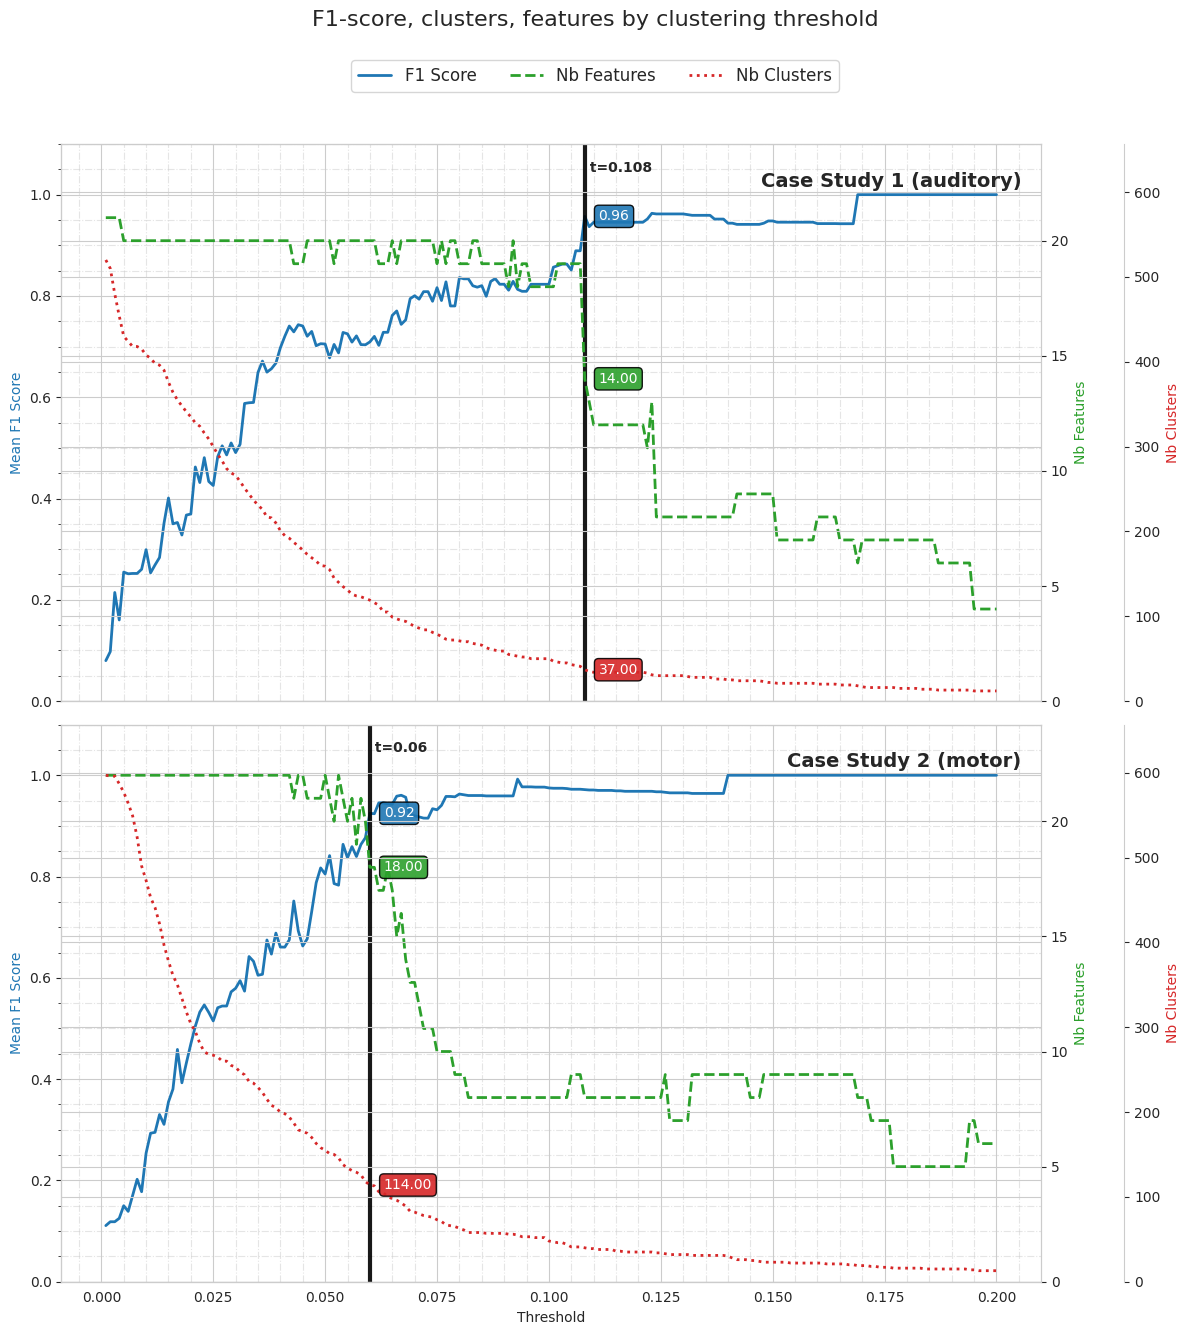

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D

# --- Data Preparation ---
# Explicitly cast thresholds to float to prevent "sequence multiplication" errors
t1_val = float(threshold_1) if hasattr(threshold_1, '__iter__') and not isinstance(threshold_1, str) else float(threshold_1)
t2_val = float(threshold_2) if hasattr(threshold_2, '__iter__') and not isinstance(threshold_2, str) else float(threshold_2)

# Ensure numeric data for calculations
for df in [classifier_valid_thresholds_1, classifier_valid_thresholds_2]:
    for col in ['train_size', 'f1_score', 'nb_clusters', 'nb_features', 'threshold']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

max_train_size_1 = classifier_valid_thresholds_1['train_size'].max()
max_train_size_2 = classifier_valid_thresholds_2['train_size'].max()

filtered_df_1 = classifier_valid_thresholds_1[classifier_valid_thresholds_1['train_size'] == max_train_size_1]
filtered_df_2 = classifier_valid_thresholds_2[classifier_valid_thresholds_2['train_size'] == max_train_size_2]

relevant_columns = ['f1_score', 'precision', 'recall','nb_clusters', 'nb_features', 'threshold']
mean_df_1 = filtered_df_1[relevant_columns].groupby('threshold').mean().reset_index()
mean_df_2 = filtered_df_2[relevant_columns].groupby('threshold').mean().reset_index()

# Styles & Scales
styles = {
    'f1_score': {'color': '#1f77b4', 'ls': '-', 'label': 'F1 Score'},
    'nb_features': {'color': '#2ca02c', 'ls': '--', 'label': 'Nb Features'},
    'nb_clusters': {'color': '#d62728', 'ls': ':', 'label': 'Nb Clusters'}
}

# Synchronized Y-axis limits
y_limits = {
    'f1': (0, max(np.nanmax(mean_df_1['f1_score']), np.nanmax(mean_df_2['f1_score'])) * 1.1),
    'feat': (0, max(np.nanmax(mean_df_1['nb_features']), np.nanmax(mean_df_2['nb_features'])) * 1.1),
    'clus': (0, max(np.nanmax(mean_df_1['nb_clusters']), np.nanmax(mean_df_2['nb_clusters'])) * 1.1)
}

# Create Figure with vertical subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14), sharex=True)

panels = [
    (ax1, mean_df_1, "Case Study 1 (auditory)", t1_val, True),
    (ax2, mean_df_2, "Case Study 2 (motor)", t2_val, False)
]

for main_ax, df, title, specific_t, is_top in panels:
    # 1. F1 Score Axis
    main_ax.plot(df['threshold'], df['f1_score'], **styles['f1_score'], linewidth=2)
    main_ax.set_ylim(y_limits['f1'])
    main_ax.set_ylabel('Mean F1 Score', color=styles['f1_score']['color'])

    if is_top:
        main_ax.set_xlabel('')  # Remove x-axis label for the top panel
    else:
        main_ax.set_xlabel('Threshold')  # Keep x-axis label for the bottom panel

    # 2. Features Axis
    ax_feat = main_ax.twinx()
    ax_feat.plot(df['threshold'], df['nb_features'], **styles['nb_features'], linewidth=2)
    ax_feat.set_ylim(y_limits['feat'])
    ax_feat.set_ylabel('Nb Features', color=styles['nb_features']['color'])

    # 3. Clusters Axis
    ax_clus = main_ax.twinx()
    ax_clus.spines['right'].set_position(('outward', 60))
    ax_clus.plot(df['threshold'], df['nb_clusters'], **styles['nb_clusters'], linewidth=2)
    ax_clus.set_ylim(y_limits['clus'])
    ax_clus.set_ylabel('Nb Clusters', color=styles['nb_clusters']['color'])

    # 4. Vertical Line & Annotations
    main_ax.axvline(x=specific_t, color='black', linestyle='-', linewidth=3, alpha=0.9)
    main_ax.text(0.98, 0.95, title, transform=main_ax.transAxes, fontsize=14, verticalalignment='top', horizontalalignment='right', fontweight='bold')

    main_ax.text(specific_t, y_limits['f1'][1]*0.97, f' t={specific_t}', fontweight='bold', va='top')

    for col, ax_ref in [('f1_score', main_ax), ('nb_features', ax_feat), ('nb_clusters', ax_clus)]:
        y_val = np.interp(specific_t, df['threshold'], df[col])
        ax_ref.annotate(f'{y_val:.2f}', xy=(specific_t, y_val), xytext=(10, 0),
                        textcoords='offset points', color='white', va='center',
                        bbox=dict(boxstyle='round,pad=0.3', fc=styles[col]['color'], ec='black', alpha=0.9))

    main_ax.minorticks_on()
    main_ax.grid(True, linestyle="-.", alpha=0.5, which='minor', axis='both')

# Unified Legend and Figure Title
legend_elements = [Line2D([0], [0], **styles[k], lw=2) for k in styles]

fig.suptitle("F1-score, clusters, features by clustering threshold",
             fontsize=16, y=0.98)

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.95),
           ncol=3, frameon=True, fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.92])
plt.savefig(os.path.join(figdir, 'clustering_thresholds_metrics.png'), format='png', bbox_inches='tight')
plt.savefig(os.path.join(figdir, 'clustering_thresholds_metrics.svg'), format='svg', bbox_inches='tight')
plt.show()
